최종 자산 평균: 1080.02
최종 자산 중앙값: 1059.74
5% 분위수: 767.03
95% 분위수: 1465.00
원금 손실 확률: 38.46%
20% 이상 손실 확률: 7.68%


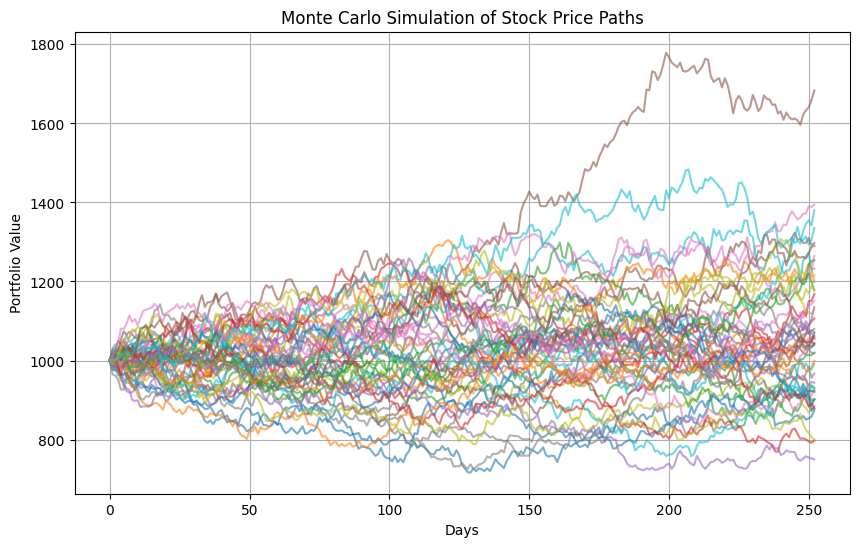

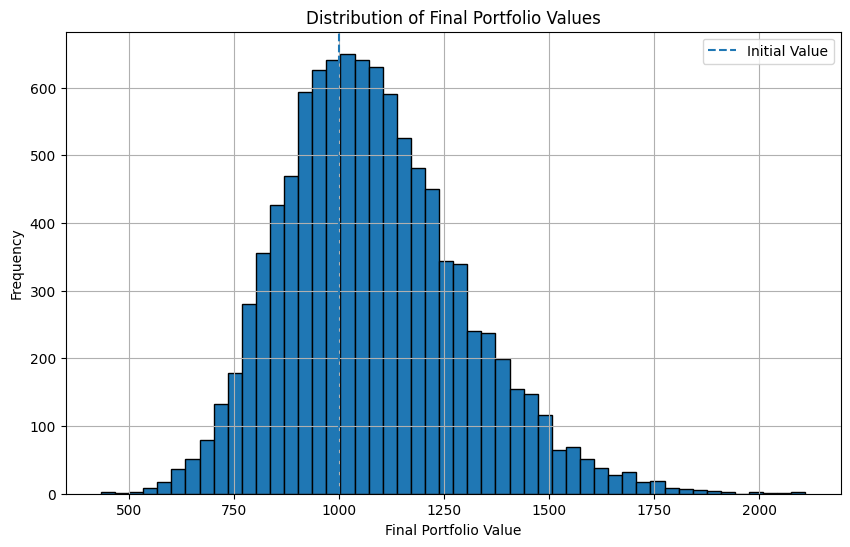

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 설정값
# -----------------------------
initial_price = 1000
mu = 0.08          # 연평균 기대수익률
sigma = 0.20       # 연변동성
days = 252         # 거래일 수
n_simulations = 10000
dt = 1 / days

# -----------------------------
# 몬테카를로 시뮬레이션
# 기하 브라운 운동(GBM) 가정
# -----------------------------
simulated_paths = np.zeros((days + 1, n_simulations))
simulated_paths[0] = initial_price

for t in range(1, days + 1):
    z = np.random.standard_normal(n_simulations)
    simulated_paths[t] = simulated_paths[t - 1] * np.exp(
        (mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * z
    )

final_prices = simulated_paths[-1]

# -----------------------------
# 요약 통계
# -----------------------------
mean_final = np.mean(final_prices)
median_final = np.median(final_prices)
p5 = np.percentile(final_prices, 5)
p95 = np.percentile(final_prices, 95)
loss_prob = np.mean(final_prices < initial_price)
minus_20_prob = np.mean(final_prices < initial_price * 0.8)

print(f"최종 자산 평균: {mean_final:.2f}")
print(f"최종 자산 중앙값: {median_final:.2f}")
print(f"5% 분위수: {p5:.2f}")
print(f"95% 분위수: {p95:.2f}")
print(f"원금 손실 확률: {loss_prob:.2%}")
print(f"20% 이상 손실 확률: {minus_20_prob:.2%}")

# -----------------------------
# 경로 일부 시각화
# -----------------------------
plt.figure(figsize=(10, 6))
plt.plot(simulated_paths[:, :50], alpha=0.6)
plt.title("Monte Carlo Simulation of Stock Price Paths")
plt.xlabel("Days")
plt.ylabel("Portfolio Value")
plt.grid(True)
plt.show()

# -----------------------------
# 최종 자산 분포 시각화
# -----------------------------
plt.figure(figsize=(10, 6))
plt.hist(final_prices, bins=50, edgecolor='black')
plt.axvline(initial_price, linestyle='--', label='Initial Value')
plt.title("Distribution of Final Portfolio Values")
plt.xlabel("Final Portfolio Value")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

하한 규격 미달 확률: 2.25%
상한 규격 초과 확률: 2.31%
전체 규격 이탈 확률: 4.56%


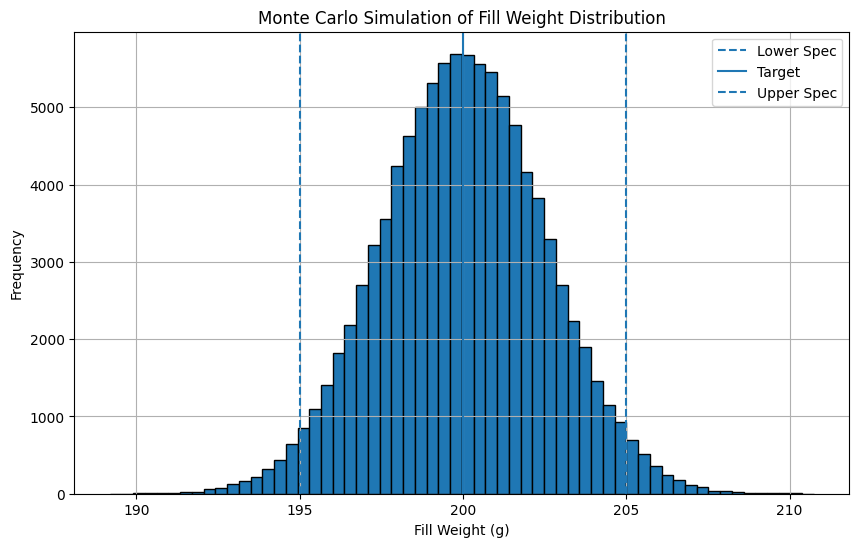

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 설정값
# -----------------------------
target_fill = 200        # 목표 충진량(g)
mean_fill = 200          # 실제 평균 충진량(g)
std_fill = 2.5           # 공정 표준편차(g)
lower_spec = 195         # 하한 규격(g)
upper_spec = 205         # 상한 규격(g)
n_simulations = 100000

# -----------------------------
# 몬테카를로 시뮬레이션
# -----------------------------
fills = np.random.normal(loc=mean_fill, scale=std_fill, size=n_simulations)

# -----------------------------
# 규격 이탈 계산
# -----------------------------
below_spec_prob = np.mean(fills < lower_spec)
above_spec_prob = np.mean(fills > upper_spec)
out_of_spec_prob = np.mean((fills < lower_spec) | (fills > upper_spec))

print(f"하한 규격 미달 확률: {below_spec_prob:.2%}")
print(f"상한 규격 초과 확률: {above_spec_prob:.2%}")
print(f"전체 규격 이탈 확률: {out_of_spec_prob:.2%}")

# -----------------------------
# 분포 시각화
# -----------------------------
plt.figure(figsize=(10, 6))
plt.hist(fills, bins=60, edgecolor='black')
plt.axvline(lower_spec, linestyle='--', label='Lower Spec')
plt.axvline(target_fill, linestyle='-', label='Target')
plt.axvline(upper_spec, linestyle='--', label='Upper Spec')
plt.title("Monte Carlo Simulation of Fill Weight Distribution")
plt.xlabel("Fill Weight (g)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

n = 10000000000

raw_moisture = np.random.normal(62.0, 1.2, n)
process_error = np.random.normal(0.0, 0.5, n)
drying_effect = np.random.normal(27.0, 0.8, n)

final_moisture = raw_moisture + process_error - drying_effect

spec_limit = 35.0
fail_prob = np.mean(final_moisture > spec_limit)

print(f"최종 수분 규격 초과 확률: {fail_prob:.2%}")
print(f"평균 최종 수분: {np.mean(final_moisture):.2f}%")
print(f"95% 상위값: {np.percentile(final_moisture, 95):.2f}%")

plt.figure(figsize=(10, 6))
plt.hist(final_moisture, bins=60, edgecolor='black')
plt.axvline(spec_limit, linestyle='--', label='Spec Limit')
plt.title("Distribution of Final Moisture")
plt.xlabel("Final Moisture (%)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()